In [28]:
# RNNによる文章生成
# 言語モデルを使った文章生成
# RNNによる文章生成の手順

In [29]:
# RnnlmGenクラスの実装
import sys
sys.path.append("..")
import numpy as np
from common.functions import softmax
from ch06.rnnlm import Rnnlm
from ch06.better_rnnlm import BetterRnnlm

class RnnlmGen(Rnnlm):
    def generate(self, start_id, skip_ids=None, sample_size=100):
        word_ids = [start_id]

        x = start_id
        while len(word_ids) < sample_size:
            x = np.array(x).reshape(1, 1)
            score = self.predict(x)
            p = softmax(score.flatten())

            sampled = np.random.choice(len(p), size=1, p=p)
            if (skip_ids is None) or (sampled not in skip_ids):
                x = sampled
                word_ids.append(int(x))

        return word_ids

In [30]:
# 文章生成する
import sys
sys.path.append("..")
from ch07.generate_text import word_ids
from rnnlm_gen import RnnlmGen
from dataset import ptb

corpus, word_to_id, id_to_word = ptb.load_data("train")
vocab_size = len(word_to_id)
corpus_size = len(corpus)

model = RnnlmGen()

# start文字とskip文字の設定
start_word = "you"
start_id = word_to_id[start_word]
skip_words = ["N", "<unk>", "s"]
skip_ids = [word_to_id[w] for w in skip_words]

# 文章生成
word_ids = model.generate(start_id, skip_ids)
txt = " ".join([id_to_word[i] for i in word_ids])
txt = txt.replace(" <eos> ", ".\n")
print(txt)

you truck kan. licensing falls entered issues california relied enterprise fast-growing invited arguments nev. patch purchased insistence creditors retains plans channel users deficit-reduction completed whooping rooms mcgovern zones presence ralston outstanding toy pa. architecture scenarios prevail appreciation liberation announcements normal spirits faster traveling responding optimistic wellcome wall swap internal gate cineplex thrift cftc steppenwolf curb popularity epo collapse lackluster cushion threatening cowboys through logic touted margin federally arctic clean item insisted co-chief day-to-day distributors prohibits used package feature asset corner spur communism bulls regarded glad wears smoke tony holding debt z insist starts dominated steal willful kenneth slump pitch nathan


In [31]:
# seq2seqの原理
# 時系列データ変換用のトイ・プロブレム
# 可変長の時系列データ

In [32]:
# 足し算データセット
import sys 
sys.path.append("..")
from dataset import sequence

(x_train, t_train), (x_test, t_test) = \
    sequence.load_data("addition.txt", seed=1984)
char_to_id, id_to_char = sequence.get_vocab()

print(x_train.shape, t_train.shape)
print(x_test.shape, t_test.shape)
print(" ")
print(x_train[0])
print(t_train[0])
print(" ")
print("".join([id_to_char[c] for c in x_train[0]]))
print("".join([id_to_char[c] for c in t_train[0]]))


(45000, 7) (45000, 5)
(5000, 7) (5000, 5)
 
[ 3  0  2  0  0 11  5]
[ 6  0 11  7  5]
 
71+118 
_189 


In [33]:
# seq2seqの実装
# Encoderクラス
from common.time_layers import TimeLSTM
from common.time_layers import TimeEmbedding


rng = np.random.default_rng()

class Encoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = rng.random

        embed_W = (rn((V, D)) / 100).astype("f")
        lstm_Wx = (rn((D, 4 * H)) / np.sqrt(D)).astype("f")
        lstm_Wh = (rn((H, 4 * H)) / np.sqrt(H)).astype("f")
        lstm_b = np.zeros(4 * H).astype("f")

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=False)

        self.params = self.embed.params + self.lstm.params
        self.grads = self.embed.grads + self.lstm.grads
        self.hs = None

    def forward(self, xs):
        xs = self.embed.forward(xs)
        hs = self.lstm.forward(xs)
        self.hs = hs
        return hs[:, -1, :]

    def backward(self, dh):
        dhs = np.zeros_like(self.hs)
        dhs[:, -1, :] = dh

        dout = self.lstm.backward(dhs)
        dout = self.embed.backward(dout)
        return dout

In [34]:
# Decoderクラス
from common.time_layers import TimeAffine


class Decoder:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = rng.random

        embed_W = (rn((V, D)) / 100).astype("f")
        lstm_Wx = (rn((D, 4 * H)) / np.sqrt(D)).astype("f")
        lstm_Wh = (rn((H, 4 * H)) / np.sqrt(H)).astype("f")
        lstm_b = np.zeros(4 * H).astype("f")
        affine_W = (rn((H, V)) / np.sqrt(H)).astype("f")
        affine_b = np.zeros(V).astype("f")

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_W, affine_b)

        self.params, self.grads = [], []
        for  layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, xs, h):
        self.lstm.set_state(h)

        out = self.embed.forward(xs)
        out = self.lstm.forward(out)
        score = self.affine.forward(out)
        return score

    def backward(self, dscore):
        dout = self.affine.backward(dscore)
        dout = self.lstm.backward(dout)
        dout = self.embed.backward(dout)
        dh = self.lstm.dh
        return dh

    # generate()を実装
    def generate(self, h, start_id, sample_size):
        sampled = []
        sample_id = start_id
        self.lstm.set_state(h)

        for _ in range(sample_size):
            x = np.array(sample_id).reshape((1, 1))
            out = self.embed.forward(x)
            out = self.lstm.forward(out)
            score = self.affine.forward(out)

            sample_id = np.argmax(score.flatten())
            sampled.append(int(sample_id))

        return sampled


In [35]:
# Seq2Seqクラスの実装
from common.base_model import BaseModel
from common.time_layers import TimeSoftmaxWithLoss


class Seq2Seq(BaseModel):
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        self.encoder = Encoder(V, D, H)
        self.decoder = Decoder(V, D, H)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

    def forward(self, xs, ts):
        decoder_xs, decoder_ts = ts[:, :-1], ts[:, 1:]

        h = self.encoder.forward(xs)
        score  =self.decoder.forward(decoder_xs, h)
        loss = self.softmax.forward(score, decoder_ts)
        return loss

    def backward(self, dout=1):
        dout = self.softmax.backward(dout)
        dh = self.decoder.backward(dout)
        dout = self.encoder.backward(dh)
        return dout

    def generate(self, xs, start_id, sample_size):
        h = self.encoder.forward(xs)
        sampled = self.decoder.generate(h, start_id, sample_size)
        return sampled

In [36]:
# seq2seqの評価
import sys
sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from dataset import sequence
from common.optimizer import Adam
from common.trainer import Trainer
from common.util import eval_seq2seq
from seq2seq import Seq2seq
from peeky_seq2seq import PeekySeq2seq

# データセットの読み込み
(x_train, t_train), (x_test, t_test) = sequence.load_data("addition.txt")
char_to_id, id_to_char = sequence.get_vocab()

# ハイパーパラメータの設定
vocab_size = len(char_to_id)
wordvec_size = 16
hidden_size = 128
batch_size = 128
max_epoch = 25
max_grad = 5.0

# モデル / オプティマイザ / トレーナーの生成
model = Seq2Seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
    batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct, id_to_char, verbose)
    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print("val acc %.3f%%" % (acc * 100))

| epoch 1 |  iter 1 / 351 | time 0[s] | loss 2.52
| epoch 1 |  iter 21 / 351 | time 0[s] | loss 2.33
| epoch 1 |  iter 41 / 351 | time 0[s] | loss 2.14
| epoch 1 |  iter 61 / 351 | time 0[s] | loss 2.06
| epoch 1 |  iter 81 / 351 | time 1[s] | loss 2.02
| epoch 1 |  iter 101 / 351 | time 1[s] | loss 1.96
| epoch 1 |  iter 121 / 351 | time 1[s] | loss 1.92
| epoch 1 |  iter 141 / 351 | time 2[s] | loss 1.89
| epoch 1 |  iter 161 / 351 | time 2[s] | loss 1.86
| epoch 1 |  iter 181 / 351 | time 2[s] | loss 1.84
| epoch 1 |  iter 201 / 351 | time 3[s] | loss 1.82
| epoch 1 |  iter 221 / 351 | time 3[s] | loss 1.81
| epoch 1 |  iter 241 / 351 | time 3[s] | loss 1.79
| epoch 1 |  iter 261 / 351 | time 4[s] | loss 1.78
| epoch 1 |  iter 281 / 351 | time 4[s] | loss 1.79
| epoch 1 |  iter 301 / 351 | time 4[s] | loss 1.78
| epoch 1 |  iter 321 / 351 | time 5[s] | loss 1.78
| epoch 1 |  iter 341 / 351 | time 5[s] | loss 1.78
Q 77+85  
T 162 
X 100 
---
Q 975+164
T 1139
X 1100
---
Q 582+84 
T 66

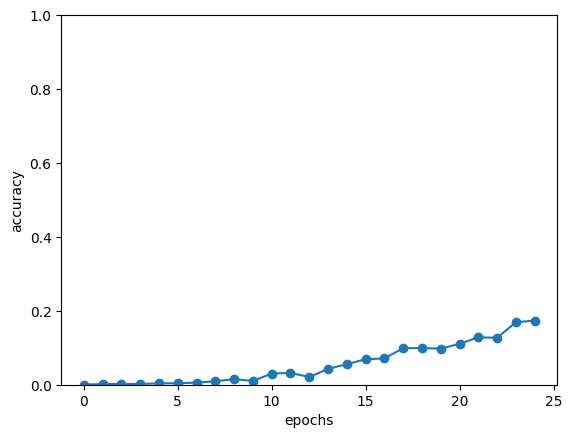

In [37]:
# グラフの描画
import matplotlib.pyplot as plt

x = np.arange(len(acc_list))
plt.plot(x, acc_list, marker="o")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.axhline(y=1.0, linestyle="--")
plt.show()

In [ ]:
# 覗き見（Peeky）
class PeekyDecoder:
    def __init__ (self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = rng.random

        embed_W = (rn((V, D)) / 100).astype("f")
        lstm_Wx = (rn((H + D, 4 * H)) / np.sqrt(H + D)).astype("f")
        lstm_Wh = (rn((H, 4 * H)) / np.sqrt(H)).astype("f")
        lstm_b = np.zeros(4 * H).astype("f")
        affine_W = (rn((H + H, V)) / np.sqrt(H + H)).astype("f")
        affine_b = np.zeros(V).astype("f")

        self.embed = TimeEmbedding(embed_W)
        self.lstm = TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True)
        self.affine = TimeAffine(affine_W, affine_b)

        self.params, self.grads = [], []
        for layer in (self.embed, self.lstm, self.affine):
            self.params += layer.params
            self.grads += layer.grads
        self.cache = None

    def forward(self, xs, h):
        N, T = xs.shape
        N, H = h.shape

        self.lstm.set_state(h)
        out = self.embed.forward(xs)
        hs = np.repeat(h, T, axis=0).reshape(N, T, H)
        out = np.concatenate((hs, out), axis=2)

        out = self.lstm.forward(out)
        out = np.concatenate((hs, out), axis=2)

        score = self.affine.forward(out)
        self.cache = H
        return score

    def backward(self, dscore):
        H = self.cache
        dout = self.affine.backward(dscore)
        dout_after_lstm = dout[:, :, H:]
        dhs0 = dout[:, :, :H]
        dout = self.lstm.backward(dout_after_lstm)

        dout_after_embed = dout[:, :, H:]
        dhs1 = dout[:, :, :H]

        self.embed.backward(dout_after_embed)
        dhs = np.sum(dhs0 + dhs1, axis=1)
        return dhs

    def generate(self, h, start_id, sample_size):
        sampled = []
        char_id = start_id
        self.lstm.set_state(h)

        H = h.shape[1]
        peeky_h = h.reshape(1, 1, H)
        
        for _ in range(sample_size):
            x = np.array(char_id).reshape((1, 1))
            out = self.embed.forward(x)  
    
            out = np.concatenate((peeky_h, out), axis=2)
            out = self.lstm.forward(out) 
    

            out = np.concatenate((peeky_h, out), axis=2) 

            score = self.affine.forward(out)
    
            char_id = np.argmax(score.flatten())
            sampled.append(int(char_id))

        return sampled

In [59]:
# PeekySeq2seqの実装
from seq2seq import Seq2seq, Encoder

class PeekySeq2seq:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        V, D, H = vocab_size, wordvec_size, hidden_size
        self.encoder = Encoder(V, D, H)
        self.decoder = PeekyDecoder(V, D, H)
        self.softmax = TimeSoftmaxWithLoss()

        self.params = self.encoder.params + self.decoder.params
        self.grads = self.encoder.grads + self.decoder.grads

    def forward(self, xs, ts):
        decoder_xs, decoder_ts = ts[:, :-1], ts[:, 1:]
        h = self.encoder.forward(xs)
        score = self.decoder.forward(decoder_xs, h)
        loss = self.softmax.forward(score, decoder_ts)
        return loss

    def backward(self, dout=1):
        dout = self.softmax.backward(dout)
        dh = self.decoder.backward(dout)
        dout = self.encoder.backward(dh)
        return dout

    def generate(self, xs, start_id, sample_size):
        h = self.encoder.forward(xs)
        sampled = self.decoder.generate(h, start_id, sample_size)
        return sampled

In [60]:
# PrrkySeq2seqの学習コード
model = PeekySeq2seq(vocab_size, wordvec_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

acc_list = []
for epoch in range(max_epoch):
    trainer.fit(x_train, t_train, max_epoch=1,
    batch_size=batch_size, max_grad=max_grad)

    correct_num = 0
    for i in range(len(x_test)):
        question, correct = x_test[[i]], t_test[[i]]
        verbose = i < 10
        correct_num += eval_seq2seq(model, question, correct, id_to_char, verbose)

    acc = float(correct_num) / len(x_test)
    acc_list.append(acc)
    print("val acc %.3f%%" % (acc * 100))

| epoch 1 |  iter 1 / 351 | time 0[s] | loss 2.57
| epoch 1 |  iter 21 / 351 | time 0[s] | loss 2.52
| epoch 1 |  iter 41 / 351 | time 0[s] | loss 2.35
| epoch 1 |  iter 61 / 351 | time 1[s] | loss 2.18
| epoch 1 |  iter 81 / 351 | time 1[s] | loss 1.98
| epoch 1 |  iter 101 / 351 | time 1[s] | loss 1.93
| epoch 1 |  iter 121 / 351 | time 2[s] | loss 1.88
| epoch 1 |  iter 141 / 351 | time 2[s] | loss 1.82
| epoch 1 |  iter 161 / 351 | time 2[s] | loss 1.79
| epoch 1 |  iter 181 / 351 | time 2[s] | loss 1.78
| epoch 1 |  iter 201 / 351 | time 3[s] | loss 1.78
| epoch 1 |  iter 221 / 351 | time 3[s] | loss 1.77
| epoch 1 |  iter 241 / 351 | time 3[s] | loss 1.77
| epoch 1 |  iter 261 / 351 | time 4[s] | loss 1.77
| epoch 1 |  iter 281 / 351 | time 4[s] | loss 1.76
| epoch 1 |  iter 301 / 351 | time 4[s] | loss 1.76
| epoch 1 |  iter 321 / 351 | time 5[s] | loss 1.76
| epoch 1 |  iter 341 / 351 | time 5[s] | loss 1.75
Q 77+85  
T 162 
X 1001
---
Q 975+164
T 1139
X 1000
---
Q 582+84 
T 66